In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [2]:
# Read the csv file
df = pd.read_csv("E:\\Statistics\\State Projects\\1\\yellow_tripdata_2019-01.csv")
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.0,1,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.0,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.0,2,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN


# Exploratory Data Analysis

In [3]:
# How Much data in the dataset
df.shape

(7667792, 18)

In [4]:
# Checks the data types all Columns
df.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

In [5]:
# Change the datatypes
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [6]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']

df['duration'] = df['duration'].dt.total_seconds() / 60

df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.50,1,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,6.666667
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.60,1,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,19.200000
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.00,1,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,4.166667
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.00,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,3.333333
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.00,2,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,1.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7667787,2,2019-01-31 23:57:36,2019-02-01 00:18:39,1,4.79,1,N,263,4,1,18.0,0.5,0.5,3.86,0.0,0.3,23.16,0.0,21.050000
7667788,2,2019-01-31 23:32:03,2019-01-31 23:33:11,1,0.00,1,N,193,193,1,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,1.133333
7667789,2,2019-01-31 23:36:36,2019-01-31 23:36:40,1,0.00,1,N,264,264,1,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.066667
7667790,2,2019-01-31 23:14:53,2019-01-31 23:15:20,1,0.00,1,N,264,7,1,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.450000


In [7]:
# Filter dataset
df = df[['passenger_count','payment_type','fare_amount','trip_distance','duration']]
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,1,7.0,1.50,6.666667
1,1,1,14.0,2.60,19.200000
2,3,1,4.5,0.00,4.166667
3,5,2,3.5,0.00,3.333333
4,5,2,52.0,0.00,1.600000
...,...,...,...,...,...
7667787,1,1,18.0,4.79,21.050000
7667788,1,1,0.0,0.00,1.133333
7667789,1,1,0.0,0.00,0.066667
7667790,1,1,0.0,0.00,0.450000


In [8]:
# Find the null value
df.isnull().sum()

passenger_count    0
payment_type       0
fare_amount        0
trip_distance      0
duration           0
dtype: int64

In [9]:
# Check How many percentage of data is null
(4855978 / len(df)) * 100

63.32954780202697

In [10]:
# Only drop null data
df.dropna(inplace = True)
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,1,7.0,1.50,6.666667
1,1,1,14.0,2.60,19.200000
2,3,1,4.5,0.00,4.166667
3,5,2,3.5,0.00,3.333333
4,5,2,52.0,0.00,1.600000
...,...,...,...,...,...
7667787,1,1,18.0,4.79,21.050000
7667788,1,1,0.0,0.00,1.133333
7667789,1,1,0.0,0.00,0.066667
7667790,1,1,0.0,0.00,0.450000


In [11]:
# Change the datatype
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')

In [12]:
# check the dublicate value
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
698,1,1,5.0,0.90,4.116667
908,1,2,6.0,1.00,5.300000
1350,1,1,5.0,0.80,4.466667
1434,1,1,8.0,2.00,6.700000
1611,1,1,6.0,0.90,6.533333
...,...,...,...,...,...
7667784,1,2,8.0,1.34,9.100000
7667788,1,1,0.0,0.00,1.133333
7667789,1,1,0.0,0.00,0.066667
7667790,1,1,0.0,0.00,0.450000


In [13]:
# Remove the dublicate data
df.drop_duplicates(inplace= True)

In [14]:
# Check the data this time have 
df.shape

(3425808, 5)

In [15]:
# Contribution in percentage
# have 3 outliers
df['passenger_count'].value_counts(normalize = True) 

passenger_count
1    0.561787
2    0.186603
5    0.075361
3    0.070345
6    0.050003
4    0.035207
0    0.020677
8    0.000008
7    0.000006
9    0.000003
Name: proportion, dtype: float64

In [16]:
# Contribution in percentage
df['payment_type'].value_counts(normalize = True) 

payment_type
1    0.671230
2    0.318469
3    0.007355
4    0.002947
Name: proportion, dtype: float64

In [17]:
df['payment_type'] = pd.to_numeric(df['payment_type'], errors='coerce')
df['passenger_count'] = pd.to_numeric(df['passenger_count'], errors='coerce')

df = df[df['payment_type'] < 3]
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 6)]

In [18]:
df.shape

(3150566, 5)

In [19]:
# Filter Categerical data
df['payment_type'].replace([1,2],['Card','Cash'],inplace = True)
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,7.0,1.50,6.666667
1,1,Card,14.0,2.60,19.200000
2,3,Card,4.5,0.00,4.166667
3,5,Cash,3.5,0.00,3.333333
4,5,Cash,52.0,0.00,1.600000
...,...,...,...,...,...
7667782,3,Card,29.5,8.14,34.700000
7667783,2,Cash,14.5,4.15,12.733333
7667785,1,Card,10.5,1.45,13.333333
7667786,2,Card,17.0,4.28,18.700000


In [20]:
# Numerical data 
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,3.150566e+06,3.150566e+06,3.150566e+06,3.150566e+06
mean,1.794917e+00,1.800783e+01,4.644597e+00,2.683531e+01
std,1.235031e+00,2.009290e+02,4.960208e+00,1.246204e+02
min,1.000000e+00,-1.030000e+02,0.000000e+00,-8.428050e+04
25%,1.000000e+00,9.000000e+00,1.500000e+00,9.950000e+00
50%,1.000000e+00,1.350000e+01,2.780000e+00,1.603333e+01
75%,2.000000e+00,2.150000e+01,5.710000e+00,2.413333e+01
max,5.000000e+00,3.556770e+05,8.318000e+02,4.364802e+04


In [21]:
df = df[df['fare_amount'] > 0]
df = df[df['trip_distance'] > 0]
df = df[df['duration'] > 0]
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,7.0,1.50,6.666667
1,1,Card,14.0,2.60,19.200000
7,1,Card,6.5,1.30,7.150000
8,1,Card,13.5,3.70,13.633333
9,2,Card,10.0,2.10,12.000000
...,...,...,...,...,...
7667782,3,Card,29.5,8.14,34.700000
7667783,2,Cash,14.5,4.15,12.733333
7667785,1,Card,10.5,1.45,13.333333
7667786,2,Card,17.0,4.28,18.700000


In [22]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,3.135818e+06,3.135818e+06,3.135818e+06,3.135818e+06
mean,1.796155e+00,1.781777e+01,4.664554e+00,2.693119e+01
std,1.235938e+00,1.454384e+01,4.959379e+00,1.141463e+02
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,9.000000e+00,1.510000e+00,1.001667e+01
50%,1.000000e+00,1.350000e+01,2.790000e+00,1.606667e+01
75%,2.000000e+00,2.150000e+01,5.750000e+00,2.416667e+01
max,5.000000e+00,6.666650e+03,8.318000e+02,4.364802e+04


In [23]:
# Find the outliers for remove (IQR)
for col in ['fare_amount','trip_distance','duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1

    lower_bound = q1 - 1.5 * (IQR)
    upper_bound = q3 + 1.5 * (IQR)

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,7.0,1.50,6.666667
1,1,Card,14.0,2.60,19.200000
7,1,Card,6.5,1.30,7.150000
8,1,Card,13.5,3.70,13.633333
9,2,Card,10.0,2.10,12.000000
...,...,...,...,...,...
7667782,3,Card,29.5,8.14,34.700000
7667783,2,Cash,14.5,4.15,12.733333
7667785,1,Card,10.5,1.45,13.333333
7667786,2,Card,17.0,4.28,18.700000


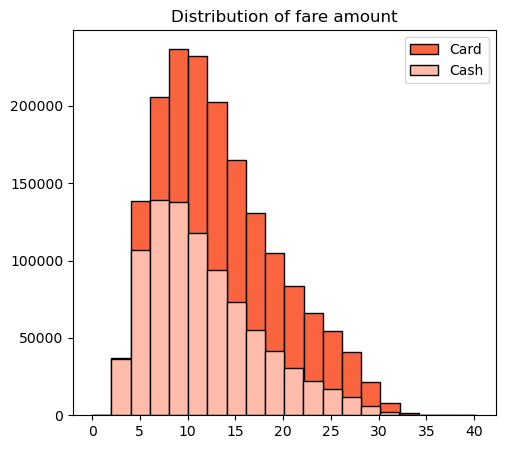

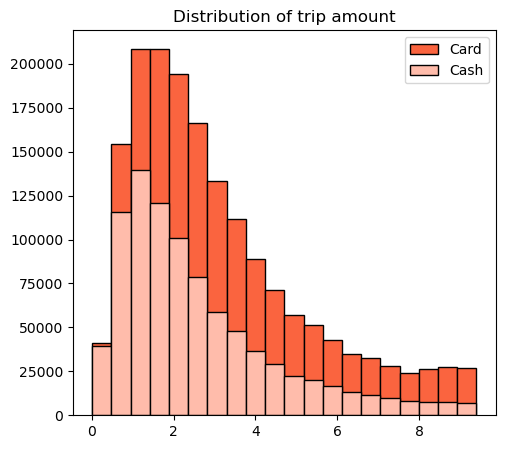

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df[df['payment_type'] == 'Card']['fare_amount'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = "Card")
plt.hist(df[df['payment_type'] == 'Cash']['fare_amount'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = "Cash")
plt.legend()
plt.title("Distribution of fare amount")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df[df['payment_type'] == 'Card']['trip_distance'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = "Card")
plt.hist(df[df['payment_type'] == 'Cash']['trip_distance'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = "Cash")
plt.legend()
plt.title("Distribution of trip amount")
plt.show()

In [25]:
# Customer Prefarred to pay most time
df.groupby('payment_type').agg({'fare_amount':['mean','std'], 'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           13.502907  6.238931      3.110102  2.157479
Cash           11.840225  5.809563      2.585949  1.944177

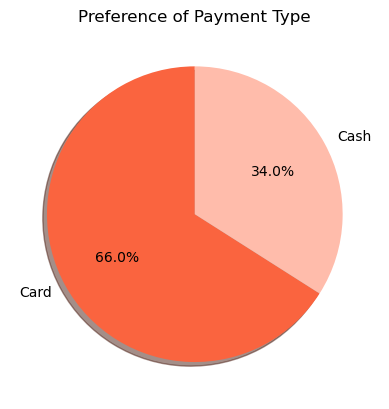

In [26]:
# Show the in charts like to pay most of time 
plt.title('Preference of Payment Type')

plt.pie(
    df['payment_type'].value_counts(normalize=True),
    labels=df['payment_type'].value_counts().index,
    startangle=90,
    shadow=True,
    autopct='%1.1f%%',
    colors=['#FA643F', '#FFBCAB']
)

plt.show()

In [27]:
passenger_count = df.groupby(
    ['payment_type', 'passenger_count']
)[['passenger_count']].count()

passenger_count.rename(
    columns={'passenger_count': 'count'},
    inplace=True
)

passenger_count.reset_index(inplace=True)

passenger_count

,payment_type,passenger_count,count
0,Card,1,990610
1,Card,2,362502
2,Card,3,145164
3,Card,4,71107
4,Card,5,160199
5,Cash,1,522970
6,Cash,2,186448
7,Cash,3,70986
8,Cash,4,38218
9,Cash,5,72824


In [28]:
passenger_count['prec'] = (passenger_count['count'] / passenger_count['count'].sum()) * 100
passenger_count

,payment_type,passenger_count,count,prec
0,Card,1,990610,37.794713
1,Card,2,362502,13.830528
2,Card,3,145164,5.538438
3,Card,4,71107,2.712943
4,Card,5,160199,6.112067
5,Cash,1,522970,19.952858
6,Cash,2,186448,7.113545
7,Cash,3,70986,2.708327
8,Cash,4,38218,1.458130
9,Cash,5,72824,2.778452


In [29]:
# Create a separate summary DataFrame (do not overwrite the main df)
payment_summary = pd.DataFrame(columns=['payment_type', 1, 2, 3, 4, 5])
payment_summary['payment_type'] = ['Card', 'Cash']
payment_summary.iloc[0, 1:] = passenger_count.iloc[0:5, -1].values
payment_summary.iloc[1, 1:] = passenger_count.iloc[5:10, -1].values
payment_summary


,payment_type,1,2,3,4,5
0,Card,37.794713,13.830528,5.538438,2.712943,6.112067
1,Cash,19.952858,7.113545,2.708327,1.45813,2.778452


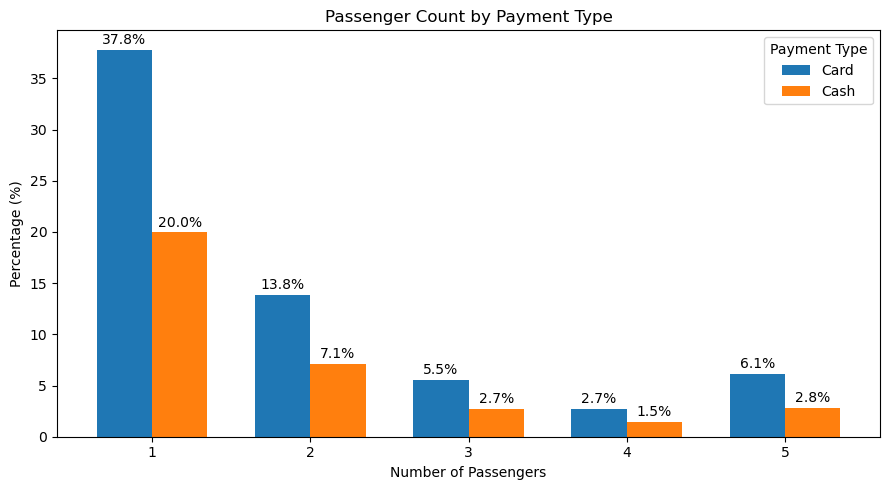

In [30]:
ax = payment_summary.set_index('payment_type').T.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.7
)

plt.title('Passenger Count by Payment Type')
plt.xlabel('Number of Passengers')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Payment Type')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()


# Null Hypothesis (H₀): There is no significant difference in average fare between credit-card and cash customers.

# Alternative Hypothesis (H₁): There is a significant difference in average fare between credit-card and cash customers.

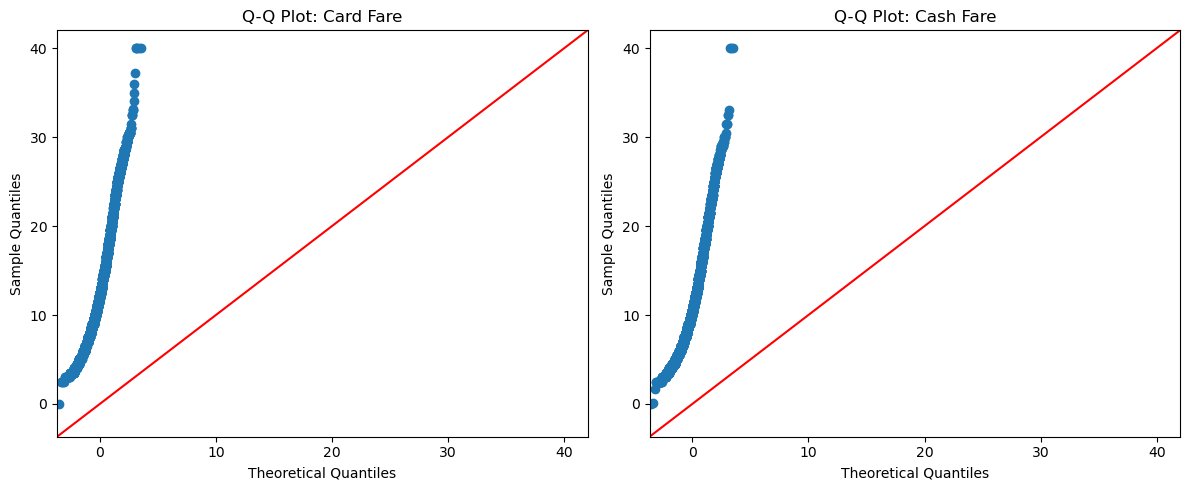

In [31]:
# Q-Q plots for fare amount in Card and Cash groups
card_fare = df.loc[df['payment_type'] == 'Card', 'fare_amount']
cash_fare = df.loc[df['payment_type'] == 'Cash', 'fare_amount']

# Use a manageable random sample for the Q-Q plots
card_qq = card_fare.sample(n=min(5000, len(card_fare)), random_state=42)
cash_qq = cash_fare.sample(n=min(5000, len(cash_fare)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sm.qqplot(card_qq, line='45', ax=axes[0])
axes[0].set_title('Q-Q Plot: Card Fare')
sm.qqplot(cash_qq, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot: Cash Fare')
plt.tight_layout()
plt.show()


In [32]:
# Select only fare_amount for each payment group
card_sample = df.loc[df['payment_type'] == 'Card', 'fare_amount']
cash_sample = df.loc[df['payment_type'] == 'Cash', 'fare_amount']

print('Card sample size:', len(card_sample))
print('Cash sample size:', len(cash_sample))


Card sample size: 1729582
Cash sample size: 891446


In [33]:
from scipy import stats as st

#t-test , p-value
t_stats, p_value = st.ttest_ind(
    card_sample,
    cash_sample,
    equal_var=False
)

print('T statistic:', t_stats)
print('p-value:', p_value)

alpha = 0.05
if p_value < alpha:
    print('Reject H0: There is a significant difference in average fare.')
else:
    print('Fail to reject H0: There is no significant difference in average fare.')


T statistic: 213.99959566606273
p-value: 0.0
Reject H0: There is a significant difference in average fare.
